# WP3 extinction repair → WP4 posterior masses → WP5 re-gate

This notebook audits the versioned `repair_v1` artifacts. It does not overwrite or recompute the frozen WP3/WP4/WP5 products. The old WP5 blocking verdict is retained as the repair trigger.

## 1. Load the frozen and repaired summaries

Purpose: establish row counts and the exact versioned files under test. The notebook intentionally reads generated products; estimator execution details and hashes live in `provenance/`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path('..').resolve()
gate = json.loads((ROOT/'provenance/wp3_repair_gate.json').read_text())
manifest = json.loads((ROOT/'provenance/wp3_wp5_repair_manifest.json').read_text())
display(pd.DataFrame([manifest['component_gates']]))
print('overall status:', manifest['status'])

,wp3_extinction_mass_invariant,wp4_mass_posterior_quality,wp5_baseline_residual,association_mass_factor_two
0,True,True,False,True


overall status: BLOCKED_WP5_BASELINE_RESIDUAL


## 2. Permanent WP3 invariant (F4)

Thresholds: in the fixed 2–12 M☉ diagnostic bins, every median `A_V − local 8-anchor map` residual must have absolute value below 0.30 mag. The rank test is applied to the bin medians (not thousands of individual stars, which would turn negligible effects into tiny p-values) and must have p ≥ 0.05. These thresholds were set in the repair brief before this run.

In [2]:
f4 = pd.read_csv(ROOT/'tables/wp3_extinction_mass_invariant_repair_v1.csv')
display(f4)
assert gate['f4']['pass']
print(gate['f4'])

,stage,count,median,mean,std,mass_lo,mass_hi
0,frozen_before_repair,459,-1.470595,-1.589915,1.210708,2.00,2.52
1,frozen_before_repair,130,-0.253168,-0.185785,0.900837,2.52,3.17
2,frozen_before_repair,170,0.151783,0.224292,0.745226,3.17,5.04
3,frozen_before_repair,77,0.613317,0.775853,1.008855,5.04,6.35
4,frozen_before_repair,58,1.844382,1.910740,0.840117,6.35,8.00
5,frozen_before_repair,118,1.491397,1.280985,1.268958,8.00,12.00
6,repair_v1,130,0.023179,0.009297,0.097246,2.00,2.52
7,repair_v1,254,-0.037806,-0.046496,0.085728,2.52,3.17
8,repair_v1,407,-0.064998,-0.077749,0.087865,3.17,5.04
9,repair_v1,128,-0.066310,-0.076941,0.102001,5.04,6.35


{'mass_bins_Msun': [2.0, 2.52, 3.17, 5.04, 6.35, 8.0, 12.0], 'max_abs_median_delta_av_mag': 0.06630994062701578, 'limit_mag': 0.3, 'binned_spearman_rho': -0.2571428571428572, 'binned_spearman_p': 0.6227871720116619, 'pvalue_limit': 0.05, 'pass': True}


## 3. WP4 posterior quality and massive-star recensus

The acceptance checks guard against discrete isochrone snapping and require the previously empty 2.5–3.2 M☉ interval to be populated. `N(>8 M☉)` is reported both from posterior medians and as the sum of per-star posterior probabilities; WP6 must not consume it while the WP5 gate is blocked.

In [3]:
mass = pd.read_parquet(ROOT/'data/processed/wp4_mass_posteriors_repair_v1.parquet')
print('largest exact fraction:', mass.mass_baseline.value_counts(normalize=True).max())
print('N 2.5–3.2:', mass.mass_baseline.between(2.5,3.2).sum())
print('median-mass N>8:', (mass.mass_baseline>8).sum())
print('posterior E[N>8]:', mass.mass_baseline_p_gt8.sum())
assert gate['wp4']['pass']

largest exact fraction: 0.007953723788864787
N 2.5–3.2: 276
median-mass N>8: 302
posterior E[N>8]: 310.90625


## 4. Honest WP5 response and unchanged residual gate

Injected six-band photometry passed through the actual repaired F1/F2 estimators. Baseline response resolution is 64 mass draws per recovered injection. The gate remains χ² p≥0.01, residual-trend p≥0.05, and maximum |Pearson residual|≤3 for every subgroup. No criterion is relaxed.

In [4]:
baseline = pd.read_parquet(ROOT/'data/processed/wp5_imf_normalization_repair_v1.parquet')
baseline = baseline.query("family == 'PARSEC' and R_V == 3.1 and alpha == 2.3")
display(baseline[['subgroup','poisson_chi_square_p','residual_trend_p',
                  'max_abs_pearson_residual','residual_gate_pass']])
assert not gate['wp5']['all_subgroups_pass']
print('Expected blocker:', gate['blocking_reason'])

,subgroup,poisson_chi_square_p,residual_trend_p,max_abs_pearson_residual,residual_gate_pass
12,CygOB2-A,0.090176,0.871743,2.626121,True
13,CygOB2-B,0.037251,0.156175,2.746391,True
14,CygOB2-C,0.039700,0.622787,3.256983,False


Expected blocker: CygOB2-C baseline WP5 max absolute Pearson residual exceeds 3


## 5. Completeness and mass sanity

No absolute 95% edge is asserted when the bright plateau itself is below 95%. Relative-to-plateau edges remain diagnostic only. The association mass must remain within a factor two of 16,500 M☉.

In [5]:
display(pd.read_csv(ROOT/'tables/wp5_completeness_baseline_repair_v1.csv'))
print(gate['wp5']['association_mass_median_Msun'],
      gate['wp5']['association_mass_lo68_Msun'],
      gate['wp5']['association_mass_hi68_Msun'])
assert gate['wp5']['within_factor_two_literature']

,subgroup,absolute_95_edge_Msun,bright_plateau_completeness,relative_95_plateau_edge_Msun_diagnostic
0,CygOB2-A,NaN,0.832500,3.25
1,CygOB2-B,NaN,0.854000,5.25
2,CygOB2-C,NaN,0.830833,4.75


31293.342406341864 30128.000755050944 32501.596534450986


## 6. Visual gate summary and decision

The left panel shows that the original mass-correlated extinction failure is removed. The right panel shows why the repair is still blocked: the converged CygOB2-C baseline response exceeds the fixed 3σ residual boundary.

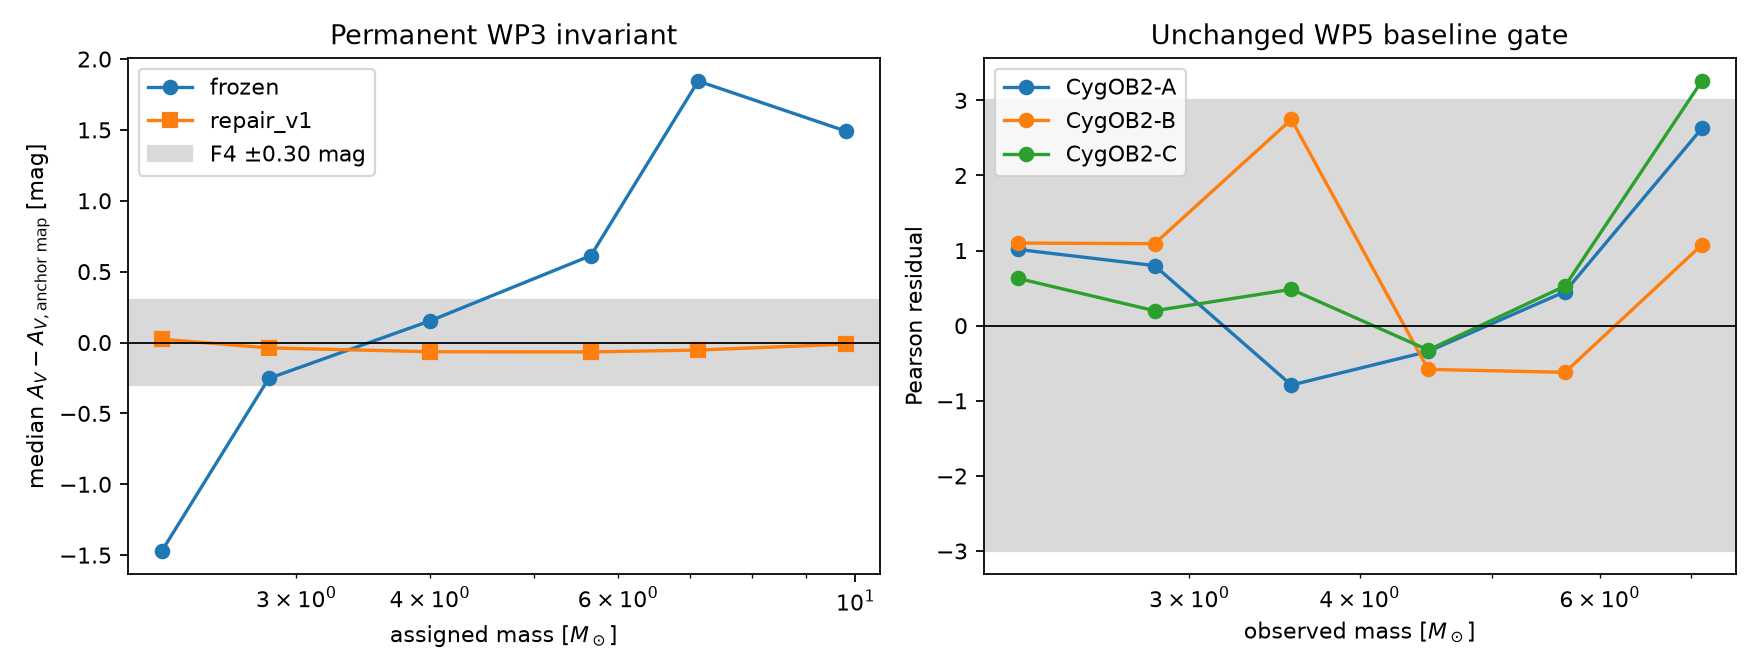

# WP3–WP5 extinction/mass repair report (repair_v1)

## Verdict

**Repair remains BLOCKED at the unchanged WP5 residual gate.** The root WP3
extinction invariant and WP4 posterior-quality criteria pass, but the converged
baseline response still leaves the following subgroup failure:

| subgroup | chi-square p | trend p | max abs residual |
|---|---:|---:|---:|
| CygOB2-C | 0.0397001 | 0.622787 | 3.25698 |

WP6 is therefore **not authorized**. The frozen WP5 blocking verdict remains
preserved as the trigger, and these versioned files are a separate repair
attempt rather than replacements.

## What was repaired

- WP3 now uses a 0.03-mag error floor in every band, an eight-anchor spatial
  prior with measured widths of 0.452/0.453/0.475 mag, and a full gridded
  extinction posterior. The hidden template-branch width is calibrated on the
  149 spectroscopic anchors from the asymmetric central-68% discrepancy.
- WP4 ages were refitted from the repaired extinction catalogue. Masses are
  posterior samples over the full extinction distribution, all available six
  bands, the binary branch, and the subgroup age posterior. The six-band model
  width is the anchor-measured 0.38 mag; the mass measure is log-uniform, not an
  IMF prior. Spectroscopic-HRD overrides are unchanged.
- WP5 retained 223,200 catalogue injections and the original residual gate.
  Synthetic photometry passes through the actual repaired WP3 and WP4
  estimators. Baseline response resolution was increased from 16 to 64 mass
  draws and shown not to remove the remaining residual.

## Acceptance checks

| check | result | pass |
|---|---:|:---:|
| max absolute binned median ΔA_V | 0.066 mag (<0.30) | True |
| binned rank-test p-value | 0.623 (>=0.05) | True |
| largest repeated baseline mass | 0.80% (<2%) | True |
| stars at 2.5–3.2 M_sun | 276 | True |
| baseline WP5 all-subgroup residual gate | — | False |
| baseline association mass | 31293 M_sun | True |
| median-mass N(>8 M_sun) | 302 | reported |
| posterior E[N(>8 M_sun)] | 310.9 | reported |

No baseline subgroup reaches an absolute 95% completeness edge. The bright
plateaus remain below 95%, so the valid statement remains a response-corrected
2–8 M_sun likelihood, **not** “95% complete.” Relative-to-plateau edges are
diagnostic only and are recorded in `tables/wp5_completeness_baseline_repair_v1.csv`.

## Remaining problem

After the extinction/mass repair, CygOB2-A and CygOB2-B pass the baseline
residual gate. CygOB2-C retains a localized excess at the high end of the
calibration interval, with max |residual| above 3 despite acceptable global
χ² and trend tests. Because this survives the 64-draw response convergence
check, changing the extinction prior or mass-likelihood width further would be
gate tuning. The next diagnostic must test the C subgroup model itself:
subgroup-label uncertainty/contamination, intrinsic age spread versus the
single-age model, and spatially varying selection. Until one of those is
modeled and injected end-to-end, WP6 must remain blocked.


In [6]:
display(Image(filename=str(ROOT/'figures/wp3_repair/wp3_wp5_repair_gates_repair_v1.png')))
display(Markdown((ROOT/'reports/WP3_WP5_REPAIR_REPORT_repair_v1.md').read_text()))